" the"


/tmp/ipykernel_51879/4250493844.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ff["corrupted"] = df_ff["corrupted"].apply(lambda x: x[1])
/tmp/ipykernel_51879/4250493844.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ff[i] = df_ff[i].apply(lambda x: x[1])
/tmp/ipykernel_51879/4250493844.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pand

,run_number,clean,corrupted,restored_token,0,1,2,3,4,5,...,39,40,41,42,43,44,45,46,47,clean_token
0,0,0.046837,0.000209,0,0.001929,-0.000110,-1.378522e-04,0.000276,-0.000012,-0.000158,...,0.000025,0.000738,0.000043,0.000058,0.000165,0.000307,0.000097,0.000096,0.000367,director
1,0,0.046837,0.000209,1,-0.000181,0.000289,3.540661e-03,0.003842,0.000155,-0.000079,...,0.000006,0.000158,-0.000135,0.010496,0.000039,0.000328,-0.000008,-0.000179,0.000310,director
2,0,0.046837,0.000209,2,-0.000022,-0.000084,-8.550970e-05,0.000167,0.000313,0.000819,...,-0.000026,0.000066,0.000656,0.000023,0.000096,-0.000003,0.000043,0.000489,-0.000148,director
3,0,0.046837,0.000209,3,0.000101,0.022976,4.697489e-04,0.001384,0.000569,0.000749,...,0.000357,-0.000025,0.000025,0.000213,-0.000020,0.000078,0.000627,-0.000100,-0.000180,director
15,3,0.093025,0.000243,0,0.000226,0.000164,5.080020e-05,0.002227,0.000764,0.002419,...,0.001084,0.000006,0.000391,-0.000076,-0.000112,0.000164,0.000138,-0.000002,0.000515,Apple
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,99,0.681151,0.000015,2,0.000051,0.000053,8.478557e-05,0.000082,0.000109,0.000330,...,0.001049,0.000893,0.000113,0.000016,0.000010,0.000074,0.000051,0.000007,0.000041,Yamaha
427,99,0.681151,0.000015,3,0.000125,0.000033,9.621708e-04,0.000045,-0.000008,0.000034,...,0.000514,0.000052,0.000063,0.000012,-0.000002,0.000035,0.000311,0.000037,0.000060,Yamaha
428,99,0.681151,0.000015,4,0.000235,0.000024,-7.528224e-07,0.000253,0.000050,0.000338,...,0.000038,0.000066,0.000099,0.000108,0.000062,-0.000006,0.000035,0.000004,0.000091,Yamaha
429,99,0.681151,0.000015,5,0.000019,0.000051,7.208841e-03,0.000247,0.000065,0.000054,...,0.000026,0.000077,0.000094,0.000887,-0.000015,0.000053,0.000053,-0.000013,0.000040,Yamaha


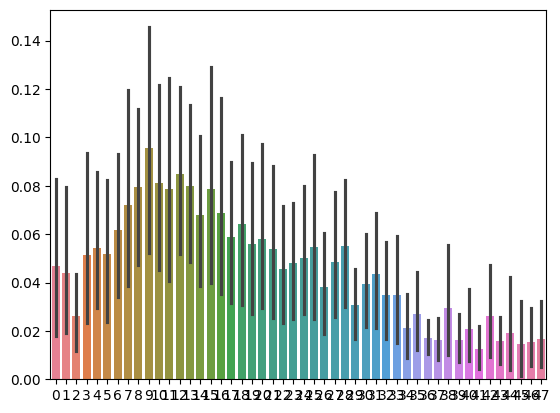

In [ ]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

result_names = [
    # "results_2025-07-29_14-29-23"
    # "results_2025-07-29_15-59-55"
    # "results_2025-07-29_16-17-03"
    # "results_2025-07-29_16-36-10",
    # "results_2025-07-30_09-10-42",
    # "results_2025-07-30_09-53-06"

    # "results_2025-07-30_11-34-34"
    # "results_2025-07-30_13-27-32"
    # "results_2025-07-30_14-41-58"
    # "results_2025-07-30_18-49-09"
    # "results_2025-07-30_19-12-39"
    # "results_2025-07-30_21-15-59"
    "results_2025-07-31_08-58-37"
]

for filename in result_names:
    df = pd.read_csv(f"{filename}.csv")

    df['clean'] = df['clean'].apply(ast.literal_eval)

    df['corrupted'] = df['corrupted'].apply(ast.literal_eval)
    df['restored'] = df['restored'].apply(ast.literal_eval)
    df_expanded = df['restored'].apply(pd.Series)
    df_final = pd.concat([df.drop('restored', axis=1), df_expanded], axis=1)

    # display(df_final)
    
    df_final["clean_token"] = df_final["clean"].apply(lambda x: x[0])
    
    print(f"\"{df_final['clean_token'][8]}\"")

    df_final["clean"] = df_final["clean"].apply(lambda x: x[1])
    
    df_ff = df_final[(df_final["clean_token"] != " the") & (df_final["clean_token"] != " of") & (df_final["clean_token"] != " to") & (df_final["clean_token"] != " at") & (df_final["clean_token"] != " a") & (df_final["clean_token"] != ' ""')]

    df_ff["corrupted"] = df_ff["corrupted"].apply(lambda x: x[1])

    for i in range(48):
        df_ff[i] = df_ff[i].apply(lambda x: x[1])
        df_ff[i] = df_ff[i] - df_ff["corrupted"]

    display(df_ff)

    df_preproc = df_ff
    df_preproc = df_preproc.drop('clean', axis=1)
    df_preproc = df_preproc.drop('corrupted', axis=1)

    # display(df_preproc)

    df_p_g = df_preproc.groupby(["run_number"]).max(["restored_token"]).drop("restored_token", axis=1)
    
    # display(df_p_g.mean())

    sns.barplot(data=df_p_g)
    plt.show()


In [ ]:
import datasets

ds = datasets.load_from_disk("../../../datasets/azhx/counterfact")
ds

In [ ]:
prompt_dict = ds["train"]["requested_rewrite"][0]
print(prompt_dict)
prompt = prompt_dict["prompt"].format(prompt_dict["subject"])
prompt

In [ ]:
import pandas
arr = pandas.DataFrame(ds["train"]["requested_rewrite"])

# arr[arr["prompt"][:2] == "{}"]

display(arr[arr["prompt"].str.startswith("{}")])